In [ ]:
###  ACA - Projeto1 - Butterfly Effect ###
###  O codigo foi iniciado no VSC e migrado para Colab com vistas a usar capacidade GPU p/Resnet50 + Imagenet  ###
###  Apesar de ter sido organizado para ser modular, nao é possível trabalhar com todos os modelos em paralelo.  ###
###  Para o caso de testar/treinar modelos - deve selecionar que conjuntos usará. Se o base ou com pretreino (pt).
###  Deve-se ajustar as configuracoes nos trechos:
###  1. Definir caminho para trabalhar
###  2. SetUp Parametros Globais e Modelos




import os
import time
import pickle
from PIL import Image
import pandas as pd
import numpy as np
import seaborn as sns # para graficos de análisis de datos
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data # para carregar os datasets
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn, optim
from torchvision import models
# from torch.utils.data import WeightedRandomSampler





In [2]:
# Definir caminho para trabalhar

# conecta com o meu GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/ACA_P1/aca-butterflies"
pathG = "/content/drive/MyDrive/ACA_P1/"

# conecta local
# path = "aca-butterflies"
# pathG = ""

Mounted at /content/drive


In [ ]:
# Importar Dataset do Kaggle - entendo que importado uma vez, nao e necessario repetir.
# Nao consegui importar, link quebrado - erro 404, segui usando o do zip fornecido.
#
# try:
#     import kagglehub #pip install kagglehub
#     kagglehub.login()
#     path = kagglehub.competition_download('aca-butterflies')
#     print("Path to dataset files:", path)

# except ImportError as e:
#     from pathlib import Path
#     path = Path().cwd()  / "aca-butterflies"


In [ ]:
# download manual modelo ResNet50
# !wget https://download.pytorch.org/models/resnet50-0676ba61.pth -O resnet50.pth


In [3]:
# SetUp Parametros Globais e Modelos
#
autor = "FBR"
#autor = "GABI"

CONFIG = {
    "image_size": 256, # 64,256 - ideal 256 para ResNet50 +PT
    "batch_size": 16, # 16, 32 - usado 16 para ResNet50 + PT
    "figsize": (16, 8),
    "train_models": False, # Use False, se quiser apenas carregar os modelos para avaliação
    "epochs": 50,
    "backbone_epochs": 5,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,  # Para o ADAMW - trata o decay separado do gradiente
    "pretrained": True, # use False, se não estiver usando um pretreino ()
    "seed": 42,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# # Modelos disponíveis, funções de perda e otimizadores
# models_to_test = ["MLP", "CNN", "ResNet"]
# loss_functions = {"CrossEntropy": nn.CrossEntropyLoss(), "MultiMargin": nn.MultiMarginLoss()}
# optimizers_types = {"ADAM": torch.optim.Adam, "RMSprop": torch.optim.RMSprop}

# Modelos com pretreino
models_to_test = ["ResNet50PT"]
loss_functions = {"CrossEntropyPT": nn.CrossEntropyLoss(label_smoothing=0.1)}
optimizers_types = {"ADAMW": torch.optim.AdamW}



In [4]:
# Transforms

base_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),

    #adicionando data augmentation para melhorar accuracy
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Estes para Pre-trainned models
base_pt_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    # transforms.Resize(256),      # para pretrained - garanto o tamanho
    transforms.CenterCrop(224),  # para pretrained
    # ----------
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_pt_transform = transforms.Compose([
    # transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.Resize(256),      # para pretrained

    # ---
    # Mudando data augmentation para melhorar accuracy
    transforms.RandomHorizontalFlip(p=0.5),               # rebater pode melhorar id das asas
    transforms.RandomRotation(10),                        # pequenas rotações - efeito voo
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),           # variação de cor
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # para pre-trainned - aumenta robustez a variação de escala

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
# Clases

class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# Criando classe homologa, mas sem os labels (nao temos GroundTruth)
class ButterflyDataset_TEST(data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name


In [6]:
# Modelos

# 1. MLP
class MLPClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.main(x)

# 2. CNN
class CNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

# 3. ResNet
def get_resnet(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

#4. ResNet50 Pre-trained
def get_resnet50pt(num_classes):
    # # se nao tem descarregado, podemos buscar aqui. Mas, travou todas as vezes e foi necessario baixar p/local.
    # model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1) # pre-treinada

    # Carrega os pesos pré-treinados manualmente
    model = models.resnet50(weights=None)
    state_dict = torch.load(f"{pathG}modelos/pretreino/resnet50.pth", map_location=CONFIG['device'])

    model.load_state_dict(state_dict)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [7]:
# Functions

# --- Análise de Distribuição de Classes ---
def analyze_class_distribution(df):
    plt.figure(figsize=CONFIG["figsize"])
    counts = df['label'].value_counts()

    # Criar o gráfico com cores variadas
    sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=0.5, saturation=0.7)

    plt.xticks(rotation=90, fontsize=7)
    plt.title(f"Distribuição de Espécies (Total: {len(counts)} classes)", fontsize=14)
    plt.xlabel("Espécie de Borboleta")
    plt.ylabel("Quantidade de Imagens")

    # Linha de média para identificar desequilíbrio (Imbalance)
    plt.axhline(counts.mean(), color='red', linestyle='--', label=f'Média: {counts.mean():.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Estatísticas rápidas
    print(f"Classe mais frequente: {counts.idxmax()} ({counts.max()} imagens)")
    print(f"Classe menos frequente: {counts.idxmin()} ({counts.min()} imagens)")
    print(f"Razão de Desequilíbrio (Max/Min): {counts.max()/counts.min():.2f}")


# --- Visualização de Amostras do Dataset ---
def visualize_samples(df, img_dir, num_samples=5):

    num_samples = min(num_samples, len(df))

    sample_df = df.sample(num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))

    if num_samples == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img_path = os.path.join(img_dir, row["filename"])

        if not os.path.exists(img_path):
            ax.set_title("Arquivo não encontrado")
            ax.axis("off")
            continue

        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"Label: {row['label']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# --- Usando sampler para balancear melhor as classes - Adicionado para ResNet50PT - Ganho marginal, removido.
# def get_weighted_sampler(dataset):
#     # Extrai os rótulos
#     targets = [label for _, label in dataset]
#     # Conta quantas imagens por classe
#     class_counts = np.bincount(targets)
#     # Peso inverso da frequência
#     class_weights = 1.0 / class_counts
#     # Peso por amostra
#     sample_weights = [class_weights[label] for label in targets]
#     # Sampler
#     sampler = WeightedRandomSampler(
#         weights=sample_weights,
#         num_samples=len(sample_weights),
#         replacement=True
#     )
#     return sampler


# --- Função auxiliar para instanciar modelos ---
def get_model(name):
    if name == "MLP":
        return MLPClassifier( input_size=3 * CONFIG["image_size"] * CONFIG["image_size"], num_classes=num_classes)
    elif name == "CNN":
        return CNNClassifier(num_classes=num_classes)
    elif name == "ResNet":
        return get_resnet(num_classes=num_classes)
    elif name == "ResNet50PT":
        return get_resnet50pt(num_classes=num_classes)
    else:
        raise ValueError(f"Modelo desconhecido: {name}")


# --- Carrega um modelo salvo a partir do nome do experimento ---
def load_model(exp_name, get_model, device):
    model_path = f"{pathG}/modelos/{autor}_best_{exp_name}.pth"
    model_type = exp_name.split("_")[0]

    model = get_model(model_type).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

# --- Avalia um modelo carregado no conjunto de validação ---
def evaluate_model(model, loader, device):
    all_labels, all_preds = predict(model, loader, device)
    acc = np.mean(np.array(all_labels) == np.array(all_preds))
    return acc

# --- Executa inferência em qualquer DataLoader ---
def predict(model, loader, device):
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds


# --------------------------------------------------------------------------
# --- Listar modelos para carregar ---
def listar_modelos_salvos(pathG, autor):
    modelos = []
    modelos_dir = os.path.join(pathG, "modelos")

    for fname in os.listdir(modelos_dir):
        if fname.startswith(f"{autor}_best_") and fname.endswith(".pth"):
            exp_name = fname.replace(f"{autor}_best_", "").replace(".pth", "")
            modelos.append(exp_name)
    modelos.sort()
    return modelos

# --- Avalia todos os modelos carregados e retorna o melhor ---
def avaliar_modelos(loaded_results, get_model, val_loader, classes, CONFIG):
    best_model_name = rank_models(loaded_results)
    model = load_model(best_model_name, get_model, CONFIG["device"])
    all_labels, all_preds = predict(model, val_loader, CONFIG["device"])
    return classes, all_labels, all_preds, best_model_name


# --- Ordena os modelos carregados pelo desempenho e retorna o melhor ---
def rank_models(loaded_results):
    sorted_results = sorted(loaded_results.items(), key=lambda x: x[1], reverse=True)

    print("\n Ranking dos modelos:\n")
    for i, (name, acc) in enumerate(sorted_results, 1):
        print(f"{i}. {name}: Acc: {acc:.4f}")

    best_model_name = sorted_results[0][0]
    print(f"\n Melhor modelo encontrado: {best_model_name}\n")
    return best_model_name


# --- Gera um DataFrame com o relatório de classificação ---
def classification_report_df(all_labels, all_preds, classes):
    report_dict = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
    return pd.DataFrame(report_dict).transpose()

# --- Plota curvas de validação dos modelos ---
def plot_training_curves(all_results):
    plt.figure(figsize=CONFIG["figsize"])

    for exp_name, result in all_results.items():
        # Converte cada valor para float, independentemente de ser tensor ou não
        val_acc = [float(v.cpu()) if hasattr(v, "cpu") else float(v)
                   for v in result["history"]["val_acc"]]
        plt.plot(val_acc, label=exp_name)

    plt.title("Curvas de Validação dos Modelos")
    plt.xlabel("Época")
    plt.ylabel("Acurácia de Validação")
    plt.legend()
    plt.grid()
    plt.show()

    #curva melhores modelos train vs val

def plot_train_val(history, title=None):
    # Extrai as curvas se existirem
    train_loss = history.get("train_loss")
    val_loss   = history.get("val_loss")
    train_acc  = history.get("train_acc")
    val_acc    = history.get("val_acc")

    # Número de epochs baseado na validação
    epochs = np.arange(1, len(val_acc) + 1)

    plt.figure(figsize=(14, 5))

    # --- Loss ---
    plt.subplot(1, 2, 1)
    if train_loss is not None:
        plt.plot(epochs, train_loss, label="Train Loss", linewidth=2)
    if val_loss is not None:
        plt.plot(epochs, val_loss, label="Val Loss", linewidth=2)
    plt.title("Loss — Train vs Val" if title is None else f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- Accuracy ---
    plt.subplot(1, 2, 2)
    if train_acc is not None:
        plt.plot(epochs, train_acc, label="Train Acc", linewidth=2)
    if val_acc is not None:
        plt.plot(epochs, val_acc, label="Val Acc", linewidth=2)
    plt.title("Accuracy — Train vs Val" if title is None else f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# --- Plota a matriz de confusão ---
def plot_confusion_matrix(all_labels, all_preds, classes, title):
    # Garantir que tudo está em CPU e como ints
    all_labels = [int(x.cpu()) if hasattr(x, "cpu") else int(x) for x in all_labels]
    all_preds  = [int(x.cpu()) if hasattr(x, "cpu") else int(x) for x in all_preds]

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    plt.show()

# --- Visualiza imagens onde o modelo errou ---
def visualize_errors(model, loader, device, classes, n_images=10):
    model.eval()
    errors = []

    # 1) Coletar imagens, previsões e rótulos reais dos erros
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            wrong = preds != labels
            for i in range(len(inputs)):
                if wrong[i]:
                    errors.append((inputs[i].cpu(), preds[i].item(), labels[i].item()))

    errors = errors[:n_images]

    # 2) Plotar
    rows = (n_images // 5) + (1 if n_images % 5 else 0)
    plt.figure(figsize=(20, 4 * rows))

    for i, (img_tensor, pred, true) in enumerate(errors):
        img = img_tensor.numpy().transpose((1, 2, 0))

        # desfazer normalização
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(rows, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Real: {classes[true]}\nPrevisto: {classes[pred]}", color="red")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
# Funcoes de Treino/Teste e avaliacao


# --- Função Treino ---
def run_epoch(model, loader, criterion, optimizer, device, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if is_train: optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)  # no lugar de argmax para manter compatibilidade com PyTorch
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)
    epoch_loss = total_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# --- Treina um único modelo com loss e optimizer específicos ---
def train_single_model(model_name, get_model, loss_fn, optimizer_class,
                       train_loader, val_loader, run_epoch, CONFIG, exp_name):

    model = get_model(model_name).to(CONFIG["device"])
    criterion = loss_fn

    if CONFIG["pretrained"]:
        optimizer = optimizer_class(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,max_lr=CONFIG["learning_rate"],steps_per_epoch=len(train_loader),epochs=CONFIG["epochs"])
    else:
        optimizer = optimizer_class(model.parameters(), lr=CONFIG["learning_rate"])
        # adicionando ajuste dinamico ao learning rate, para melhorar a curva (refina pesos)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, patience=3, factor=0.5, mode='max')


    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0
    # configurando early stop, pq vou aumentar para 50 epochs
    patience_counter = 0
    early_stop_patience = 8

    # === FASE 1 - Treinar Classificador  ================
    if CONFIG["pretrained"]:
        print(f"\n--- Executando FASE FC: {exp_name} ---")
        # Congela BackBone
        for name, param in model.named_parameters():
            if not name.startswith("fc"):  # congela tudo exceto a fully-connected
                param.requires_grad = False

        for epoch in range(CONFIG["backbone_epochs"]):
            t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, CONFIG["device"], is_train=True)
            v_loss, v_acc = run_epoch(model, val_loader, criterion, None, CONFIG["device"], is_train=False)
            print(f"Fase 1 - FC - Epoch {epoch}, acc: {v_acc}")

        # Descongela tudo
        for param in model.parameters():
            param.requires_grad = True

    print(f"\n--- Executando FASE Treino Normal: {exp_name} ---")
    # === FASE 2 - Treino Normal  ================

    for epoch in range(CONFIG["epochs"]):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, CONFIG["device"], is_train=True)
        v_loss, v_acc = run_epoch(model, val_loader, criterion, None, CONFIG["device"], is_train=False)

        history["val_acc"].append(v_acc)
        history["train_acc"].append(t_acc)
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)


        # chamando o scheduler
        if CONFIG["pretrained"]:
            scheduler.step()      # OneCycleLR
        else:
            scheduler.step(v_acc)     # ReduceLROnPlateau

        if v_acc > best_acc:
            best_acc = v_acc
            # patience do early stop
            patience_counter = 0
            torch.save(model.state_dict(), f"{pathG}modelos/{autor}_best_{exp_name}.pth")
        else:
            patience_counter += 1

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch: {epoch}, LR: {current_lr:.6f}, patience_counter: {patience_counter}, acc: {v_acc}")

        if patience_counter >= early_stop_patience:
            print(f"Early stopping no epoch {epoch}")
            break

    with open(f"{pathG}modelos/historico/{autor}_history_{exp_name}.pkl", "wb") as f:
        pickle.dump(history, f)
    return best_acc, history


def Treinar(models_to_test, loss_functions, optimizers_types,
            train_loader, val_loader, get_model, run_epoch,
            CONFIG):
    if CONFIG["train_models"]:
        Treinar_Modelos(models_to_test, loss_functions, optimizers_types,
                    train_loader, val_loader, get_model, run_epoch, CONFIG)
    return Carregar_Modelos(val_loader, get_model, CONFIG)


# --- Treina todos os modelos × losses × otimizadores (3×2×2 = 12 experimentos) ---
# def Treinar_OLD(models_to_test, loss_functions, optimizers_types,
#             train_loader, val_loader, get_model, run_epoch,
#             CONFIG):
#     results = {}
#     results_history = {}

#     # --- Gera automaticamente todas as combinações ---
#     experiments = []
#     for model_name in models_to_test:
#         for loss_name, loss_fn in loss_functions.items():
#             for opt_name, opt_class in optimizers_types.items():
#                 exp_name = f"{model_name}_{loss_name}_{opt_name}"
#                 experiments.append((exp_name, model_name, loss_fn, opt_class))

#     # --- Loop principal: treina ou carrega cada experimento ---
#     for exp_name, model_name, loss_fn, opt_class in experiments:

#         print(f"\n--- Executando experimento: {exp_name} ---")

#         if CONFIG["train_models"]:
#             # Treina e salva internamente o melhor modelo
#             best_acc, history = train_single_model(
#                 model_name, get_model, loss_fn, opt_class, train_loader, val_loader, run_epoch, CONFIG, exp_name
#             )

#         # Apenas carrega e avalia
#         model = load_model(exp_name, get_model, CONFIG["device"])
#         val_acc = evaluate_model(model, val_loader, CONFIG["device"])

#         # Carrega o history salvo
#         with open(f"{pathG}modelos/historico/{autor}_history_{exp_name}.pkl", "rb") as f:
#             history = pickle.load(f)

#         # Guarda resultados
#         results[exp_name] = val_acc
#         results_history[exp_name] = {
#             "history": history,
#             "val_acc": val_acc,
#             "model_path": f"{pathG}modelos/{autor}_best_{exp_name}.pth"
#         }

#     return results, results_history

def Treinar_Modelos(models_to_test, loss_functions, optimizers_types,
                    train_loader, val_loader, get_model, run_epoch, CONFIG):

    for model_name in models_to_test:
        for loss_name, loss_fn in loss_functions.items():
            for opt_name, opt_class in optimizers_types.items():

                exp_name = f"{model_name}_{loss_name}_{opt_name}"
                print(f"\n--- Executando experimento: {exp_name} ---")

                best_acc, history = train_single_model(
                    model_name, get_model, loss_fn, opt_class,
                    train_loader, val_loader, run_epoch, CONFIG, exp_name
                )

                print(f"\n--- Treino Finalizado: {exp_name} - Best_Acc: {best_acc} ---")


def Carregar_Modelos(val_loader, get_model, CONFIG):

    modelos_salvos = listar_modelos_salvos(pathG, autor)
    results = {}
    results_history = {}

    for exp_name in modelos_salvos:
        print(f"\nCarregando experimento salvo: {exp_name}")

        model = load_model(exp_name, get_model, CONFIG["device"])
        val_acc = evaluate_model(model, val_loader, CONFIG["device"])

        # Carrega o history salvo
        with open(f"{pathG}modelos/historico/{autor}_history_{exp_name}.pkl", "rb") as f:
            history = pickle.load(f)

        results[exp_name] = val_acc
        results_history[exp_name] = {
            "history": history,
            "val_acc": val_acc,
            "model_path": f"{pathG}modelos/{autor}_best_{exp_name}.pth"
        }

    return results, results_history


# Novo predict para teste - sem labels (nao temos GroundTruth)
def predict_test(model, loader, device, class_names):
    model.eval()
    preds = []
    names = []

    with torch.no_grad():
        for inputs, img_names in loader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            for name, pred in zip(img_names, predicted.cpu().numpy()):
                preds.append(class_names[pred])   # ← classe em texto
                names.append(name)

    return names, preds


In [9]:
# Pipeline Execucao - Bloco1 - load df_full

img_dir = os.path.join(path, 'train')
df_full = pd.read_csv(os.path.join(path, 'train.csv'))

# Visualização da distribuição
# analyze_class_distribution(df_full)
# visualize_samples(df_full, img_dir)

# ----

#Split Treino/Validação
train_df, val_df = train_test_split(
   df_full, test_size=0.2, stratify=df_full['label'], random_state=CONFIG["seed"]
)

print(f"Dataset de treino {len(train_df)} e validacao {len(val_df)}")


Dataset de treino 4159 e validacao 1040


In [10]:
# Pipeline Execucao - Bloco2 - Data Loaders

# Criar Datasets e DataLoaders
if CONFIG["pretrained"]:
    train_dataset = ButterflyDataset(train_df, img_dir, train_pt_transform)
    val_dataset = ButterflyDataset(val_df, img_dir, base_pt_transform)
else:
    train_dataset = ButterflyDataset(train_df, img_dir, train_transform)
    val_dataset = ButterflyDataset(val_df, img_dir, base_transform)

# Dataset controlado para tentar rebalancear as classes
# train_loader = data.DataLoader(train_dataset, batch_size=CONFIG["batch_size"], sampler=get_weighted_sampler(train_dataset)) - obsoleto: ganho marginal
train_loader = data.DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

num_classes = len(train_dataset.classes)
print(f"Dataset de treino e loaders prontos. Total de classes: {num_classes}")


Dataset de treino e loaders prontos. Total de classes: 75


In [11]:
# Pipeline Execucao - Bloco3 - Treino Efetivamente

# Treinar ou Carregar Modelos
# Para treinar, "train_models"=True no CONFIG. Para carregar modelos já treinados, defina "train_models"= False (default) no CONFIG
# Atenção: os modelos ficam na pasta /modelos. Para carregar e avaliar somente, deve manter na pasta somente 1 conjunto (base/pretreinado), acorde ao que usou no CONFIG.


loaded_results, loaded_results_history = Treinar(
    models_to_test, loss_functions, optimizers_types,
    train_loader, val_loader,
    get_model, run_epoch,
    CONFIG
)




Carregando experimento salvo: ResNet50PT_CrossEntropyPT_ADAMW


In [12]:
# Pipeline Execucao - Bloco4
# Avaliar modelos carregados e setear o melhor modelo para teste final
model_eval = avaliar_modelos(loaded_results, get_model, val_loader, train_dataset.classes, CONFIG)
classes, all_labels, all_preds, best_model_name = model_eval

# Relatório de classificação do melhor modelo no conjunto de validação
report_df = classification_report_df(all_labels, all_preds, classes)
display(report_df.sort_values(by="f1-score", ascending=False))



 Ranking dos modelos:

1. ResNet50PT_CrossEntropyPT_ADAMW: Acc: 0.9538

 Melhor modelo encontrado: ResNet50PT_CrossEntropyPT_ADAMW



,precision,recall,f1-score,support
AFRICAN GIANT SWALLOWTAIL,1.000000,1.000000,1.000000,12.0
AMERICAN SNOOT,1.000000,1.000000,1.000000,12.0
APPOLLO,1.000000,1.000000,1.000000,14.0
AN 88,1.000000,1.000000,1.000000,14.0
BECKERS WHITE,1.000000,1.000000,1.000000,13.0
...,...,...,...,...
EASTERN COMA,0.916667,0.733333,0.814815,15.0
CLOUDED SULPHUR,0.750000,0.800000,0.774194,15.0
LARGE MARBLE,0.687500,0.846154,0.758621,13.0
PURPLISH COPPER,0.619048,0.866667,0.722222,15.0


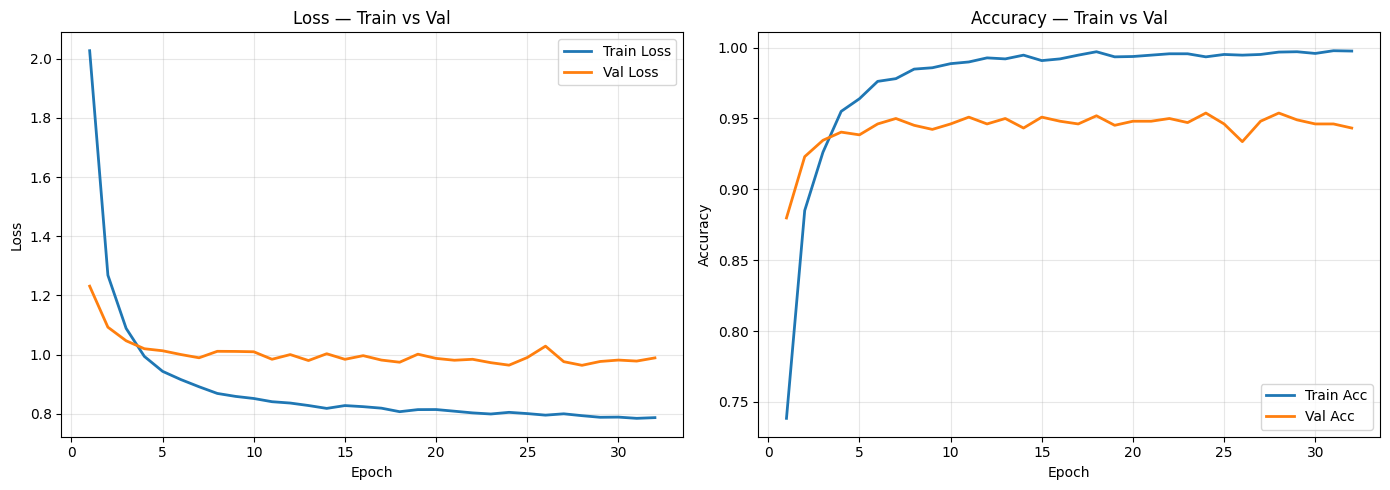

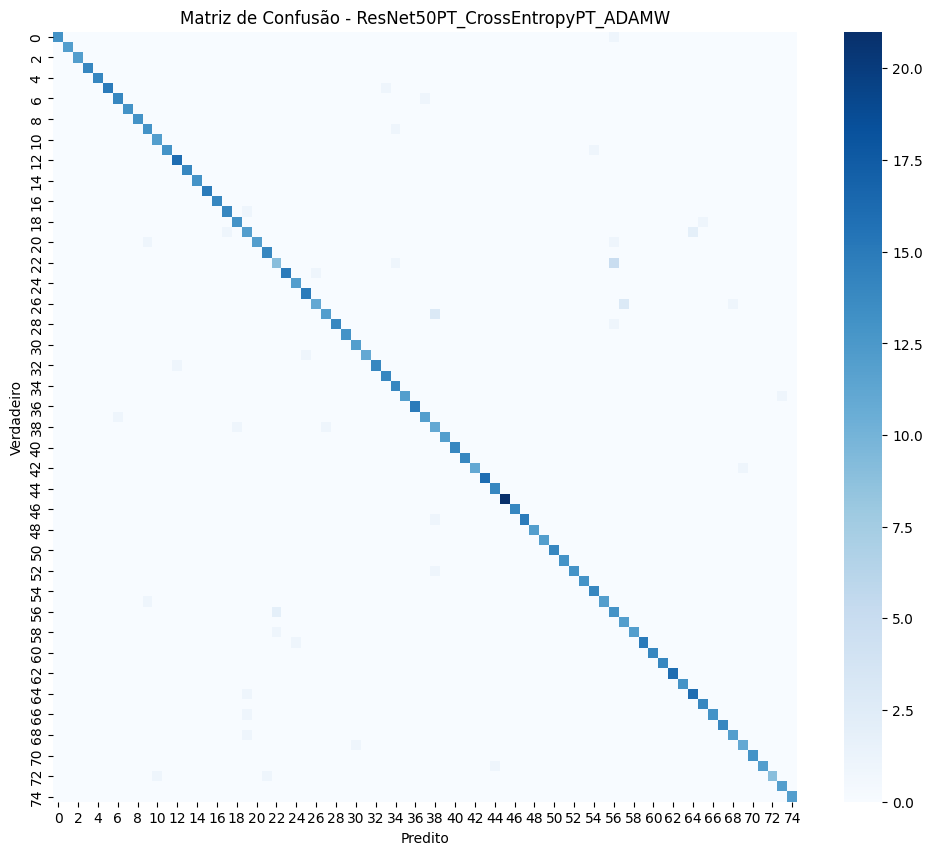

In [13]:
# Pipeline Execucao - Bloco5 - Analises
best_model = load_model(best_model_name, get_model, CONFIG["device"])


# Curvas de validação dos modelos
# plot_training_curves(loaded_results_history)

# Curva de acompanhamento treino vs validacao - para melhores modelos nas curvas de validacao.
plot_train_val(loaded_results_history[best_model_name]["history"])


# Matriz de confusão do melhor modelo no conjunto de validação
plot_confusion_matrix(all_labels, all_preds, classes, f"Matriz de Confusão - {best_model_name}")



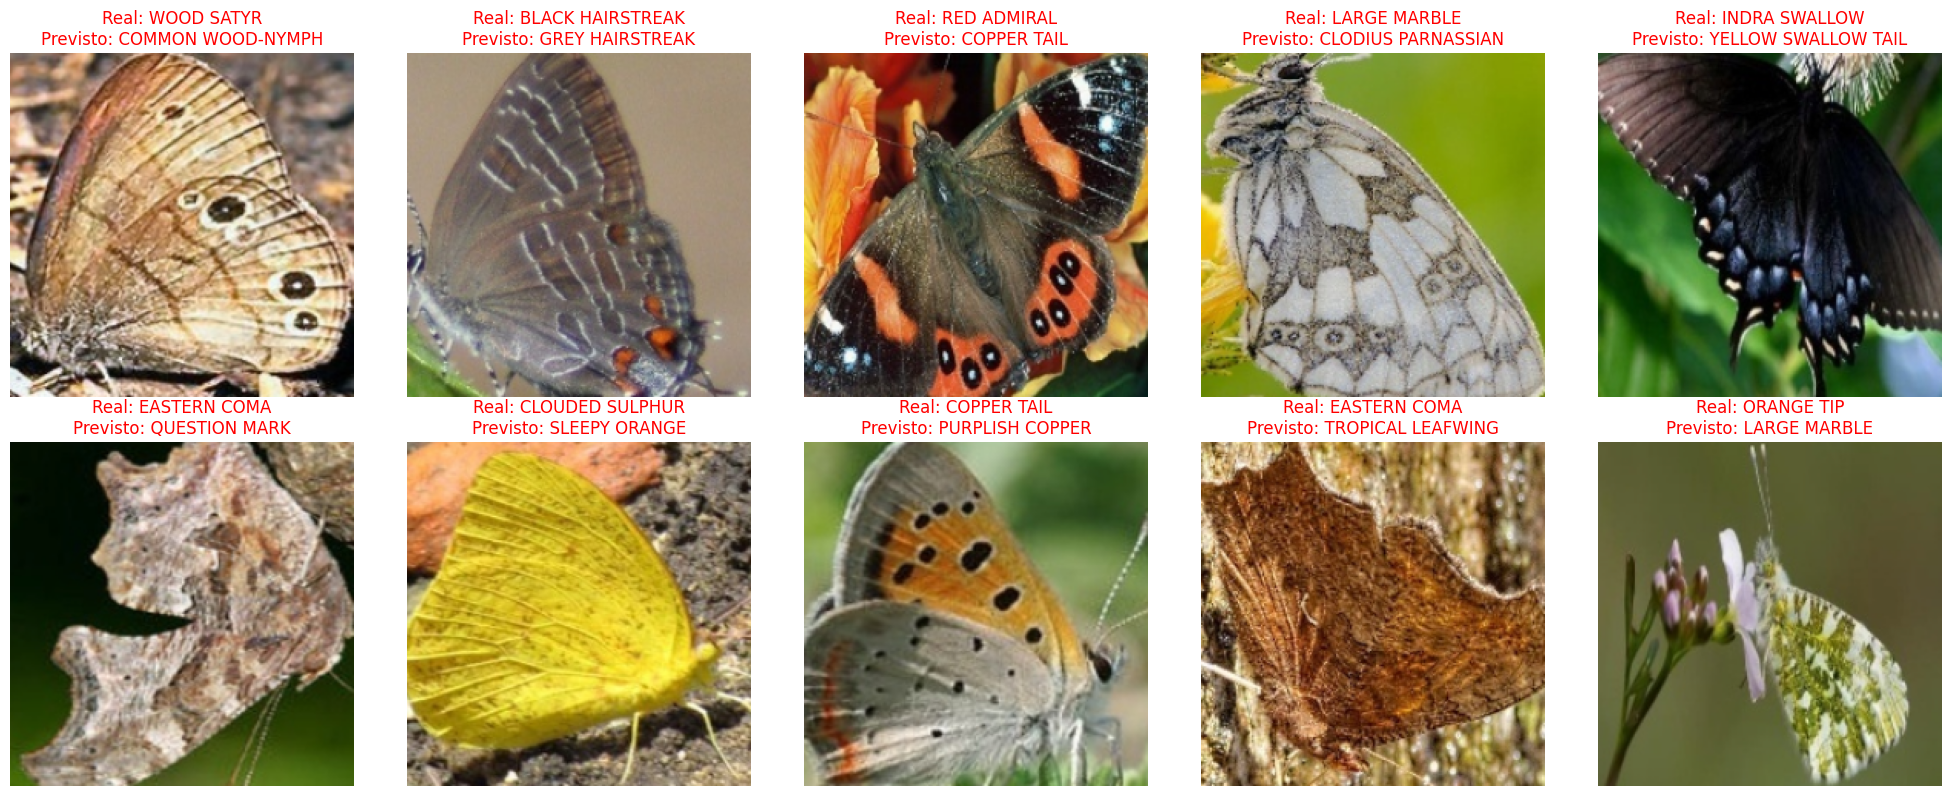

In [14]:
# Visualizar erros de classificação do melhor modelo no conjunto de validação

visualize_errors(best_model, val_loader, CONFIG["device"], train_dataset.classes)

In [15]:
# Pipeline Execucao - Bloco6 - Teste!
from datetime import datetime

# load test
if CONFIG["pretrained"]:
  test_dataset = ButterflyDataset_TEST(img_dir=os.path.join(path, 'test'), transform=base_pt_transform)
else: test_dataset = ButterflyDataset_TEST(img_dir=os.path.join(path, 'test'), transform=base_transform)

test_loader = data.DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=True)

# load_best_model
best_model = load_model(best_model_name, get_model, CONFIG["device"])

names, preds = predict_test(best_model, test_loader, CONFIG["device"], train_dataset.classes)

df_test = pd.DataFrame({"filename": names, "label": preds})

datahora = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
df_test.to_csv(f"{pathG}resultados/FBR_GABI_submission_{datahora}.csv", index=False)

from datetime import datetime

datahora = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

print(f"Teste Finalizado. Total de imagens classificadas: {len(df_test)}")

Teste Finalizado. Total de imagens classificadas: 1326


In [ ]:
#  Trata arquivo gerado e prepara submissao segundo pede asignment

# import pandas as pd
# import os

caminho_base = "/content/drive/MyDrive/TP1-Students/resultados/FBR_GABI_submission_base_2026-03-28_11-54-45.csv"
caminho_pretreino = "/content/drive/MyDrive/TP1-Students/resultados/FBR_GABI_submission_pretreino_2026-03-27_20-04-37.csv"

official_filenames = [f"Image_{i}.jpg" for i in range(1300)]

def criar_submissao_limpa(input_path, nome_saida):
    if not os.path.exists(input_path):
        print(f"arquivo não encontrado em {input_path}")
        return

    df = pd.read_csv(input_path)

    if 'Id' in df.columns:
        df = df.rename(columns={'Id': 'filename'})

    # Mantém apenas as 1300 imagens oficiais e remove qualquer duplicata ou imagem extra
    df_final = df[df['filename'].isin(official_filenames)].drop_duplicates(subset=['filename'])

    if len(df_final) != 1300:
        print(f" O arquivo {nome_saida} gerou {len(df_final)} linhas (esperado: 1300).")
        faltantes = set(official_filenames) - set(df_final['filename'])
        if faltantes:
            df_missing = pd.DataFrame({'filename': list(faltantes), 'label': 'UNKNOWN'})
            df_final = pd.concat([df_final, df_missing])

    df_final = df_final.sort_values('filename')

    # Salvar o CSV
    output_path = f"/content/drive/MyDrive/TP1-Students/resultados/{nome_saida}"
    df_final[['filename', 'label']].to_csv(output_path, index=False)
    print(f"✅ Submissão criada: {output_path}")

criar_submissao_limpa(caminho_base, "submission_modelo_base.csv")
criar_submissao_limpa(caminho_pretreino, "submission_modelo_pretreino.csv")

✅ Submissão criada: /content/drive/MyDrive/TP1-Students/resultados/submission_modelo_base.csv
✅ Submissão criada: /content/drive/MyDrive/TP1-Students/resultados/submission_modelo_pretreino.csv
